# 09 · Find roots and justify the search

**Time:** 110–120 minutes plus optional refinement. **Preparation:** Lectures 06–08, the intermediate and mean value theorems. **Lab:** [Root isolation and coverage](../labs/lab09_validated_roots.ipynb).

Objectives: distinguish exclusion, existence, uniqueness, and completeness; derive interval Newton; inspect a search record; and retain unresolved regions when a test cannot decide.

## Google Colab setup — run this cell first

**Local Jupyter:** this cell skips Colab setup; use your installed course environment.

Use a **CPU Python runtime** (Python 3.12 or newer). Run the next cell and select
**vc_runtime.zip** from this edition when prompted. It loads the course helpers
and installs the arithmetic libraries. Repeat setup whenever you get a new runtime.
No Drive mounting or local Python installation is required.
Use this setup instead of the local installation and kernel-selection instructions
in the original course text.

Save a copy of this notebook in Drive, or download it after editing. Files created
by the project are under `/content/validated-course/build/certificates/`; download
those separately from Colab's Files panel. Runtime files are temporary.

Open other course notebooks using **File → Upload notebook**, choosing them from
the extracted course folder. Relative course links are intended for local Jupyter
and do not open sibling notebooks automatically in Colab. In labs, complete exercise
cells before running their diagnostics: `NotImplementedError` marks an unfinished task.


In [1]:
try:
    import google.colab
except ImportError:
    print("Local Jupyter: using the installed course environment.")
else:
    import hashlib
    from pathlib import Path
    import subprocess
    import sys
    from google.colab import files

    if sys.version_info < (3, 12):
        raise RuntimeError("This course needs a Python 3.12 or newer Colab runtime.")

    # Upload the small companion file supplied with the Colab course edition.
    expected_hash = '833652c4a440f1c3a22bc6e68c59d533b41e6f9f1ff0b4af226f8fbee2244c1a'
    runtime_zip = Path("/content") / ("vc-course-" + expected_hash + ".zip")
    if not runtime_zip.exists():
        print("Select vc_runtime.zip from the extracted Colab course folder.")
        uploaded = files.upload()
        if len(uploaded) != 1:
            raise ValueError("Upload only vc_runtime.zip, then run this cell again.")
        archive_bytes = next(iter(uploaded.values()))
        if hashlib.sha256(archive_bytes).hexdigest() != expected_hash:
            raise ValueError("Wrong vc_runtime.zip: use the one supplied with this notebook.")
        runtime_zip.write_bytes(archive_bytes)

    if hashlib.sha256(runtime_zip.read_bytes()).hexdigest() != expected_hash:
        raise ValueError("The cached vc archive has changed; start a fresh runtime.")

    # Keep Colab's existing NumPy and plotting stack when they satisfy these bounds.
    # Install MPFR/Arb bindings, not the full local Jupyter environment.
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "--quiet",
        'numpy>=1.26', 'matplotlib>=3.8', 'gmpy2==2.3.1', 'python-flint==0.9.0', 'jupytext>=1.16'
    ])
    import gmpy2
    import flint
    if gmpy2.version() != "2.3.1" or flint.__version__ != "0.9.0":
        raise RuntimeError("Old arithmetic libraries are still loaded. Restart the session and run setup first.")

    if str(runtime_zip) not in sys.path:
        sys.path.insert(0, str(runtime_zip))

    import vc
    if not vc.__file__.startswith(str(runtime_zip) + "/"):
        raise RuntimeError("Another vc copy is already loaded. Start a fresh runtime.")

    # Preserve the relative output paths used by the project notebooks.
    import os
    working_folder = Path("/content/validated-course") / 'notebooks'
    working_folder.mkdir(parents=True, exist_ok=True)
    os.chdir(working_folder)
    print("Course helpers ready:", vc.__version__)

Local Jupyter: using the installed course environment.


In [2]:
from fractions import Fraction
from collections import Counter
import inspect
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from vc.intervals import RationalInterval as Interval
from vc.autodiff import Dual
from vc.roots import inspect_root, isolate_roots

def f(X):
    return X*X - 2

def derivative(X):
    return f(Dual(X, Interval(1))).derivative

## EXPERIMENT · An approximation suggests a question

Newton iteration from 1.5 quickly suggests √2. Its small residual does not itself give an interval containing a root or an all-roots statement. We will certify a specified interval instead.

In [3]:
guess = 1.5
for step in range(5):
    guess = guess - (guess*guess - 2)/(2*guess)
print("Approximate root:", guess, "residual:", guess*guess - 2)

left_value = f(Interval(1))
right_value = f(Interval(2))
assert left_value.hi < 0 < right_value.lo
print("Exact opposite signs at 1 and 2 establish existence by continuity.")

Approximate root: 1.414213562373095 residual: -4.440892098500626e-16
Exact opposite signs at 1 and 2 establish existence by continuity.


## THEORY · Four different conclusions

- **Exclusion:** if 0∉F(X), no root lies in X.
- **Existence:** continuous f with certified opposite endpoint signs has a root between them.
- **Uniqueness:** if a valid derivative interval excludes zero, f is strictly monotone on X and has at most one root there.
- **Completeness:** every root in the original domain is accounted for by certified intervals, with no unresolved regions left.

A zero-containing image provides none of the missing conclusions. A derivative excluding zero proves at most one root, not existence. A certificate on [1,2] says nothing about the negative root outside that interval.

## THEORY · Derive interval Newton

Assume f is continuously differentiable on a neighborhood of X=[a,b], let m be its exact midpoint, and suppose D encloses f′(X) with 0∉D. Let C enclose f(m). Define

$$N(X)=[m,m]-C/D.$$

If r∈X is a root, the mean value theorem gives 0=f(m)+f′(ξ)(r−m), hence r=m−f(m)/f′(ξ)∈N(X). Therefore **every root in X survives intersection with N(X)**.

Consequences: an empty intersection excludes all roots in X; otherwise it can contract the set of possible roots. No existence premise has been smuggled into the contraction argument.

In [4]:
domain = Interval(1, 2)
center = Interval(domain.midpoint())
center_value = f(center)
slopes = derivative(domain)
newton_image = center - center_value / slopes
retained = domain.intersection(newton_image)
print("Derivative bounds:", slopes)
print("Newton image:", newton_image)
print("Retained:", retained)
assert retained.lo**2 < 2 < retained.hi**2

Derivative bounds: [2, 4]
Newton image: [11/8, 23/16]
Retained: [11/8, 23/16]


## THEORY · A conservative existence and uniqueness test

Under the preceding hypotheses, our success test is **N(X) strictly inside X**. This implies exactly one root in X, and that root belongs to X∩N(X).

Here is a one-dimensional proof. Suppose D is positive. For every allowed slope d, the line f(m)+d(t−m) crosses zero at m−f(m)/d, inside X by the Newton inclusion. Thus each such line is negative at a and positive at b. Apply the mean value theorem separately between m and each endpoint: the actual endpoint values have these signs. Continuity gives existence, and the positive derivative gives uniqueness. For negative D reverse the signs. The computed C may be wider than {f(m)}; it still contains the line crossings used by the proof.

Tucker §5.1.3 gives interval Newton results under its stated smoothness assumptions. We prove the C¹ scalar version above and deliberately require strict inclusion. Boundary cases can remain unresolved even when a different theorem or an exact calculation could settle them.

In [5]:
decision = inspect_root(f, derivative, domain)
print("Status:", decision.status)
assert decision.status == "certified"
assert decision.domain.lo < decision.newton.lo
assert decision.newton.hi < decision.domain.hi
print(inspect.getsource(inspect_root))

Status: certified
def inspect_root(evaluate, derivative, domain):
    image = evaluate(domain)
    if not image.contains(0):
        return RootDecision(domain, image, "excluded_range")
    slopes = derivative(domain)
    if slopes.contains(0):
        return RootDecision(domain, image, "split", slopes)
    center = Interval(domain.midpoint())
    newton = center - evaluate(center) / slopes
    retained = domain.intersection(newton)
    if retained is None:
        return RootDecision(domain, image, "excluded_newton", slopes, newton)
    if domain.lo < newton.lo and newton.hi < domain.hi:
        return RootDecision(domain, image, "certified", slopes, newton, retained)
    if retained.width() < domain.width() / 2:
        return RootDecision(domain, image, "contract", slopes, newton, retained)
    return RootDecision(domain, image, "split", slopes, newton, retained)



## THEORY · Preserve the root set through a search

The search maintains pending intervals. Each step excludes a region, certifies its one root, contracts without losing a root, or replaces a box by two covering children. Small undecided boxes become **unresolved**; if the step budget is exhausted, all pending boxes are also returned unresolved.

Induction gives the invariant: every original root lies in a pending, certified, or unresolved interval. The decision record retains the original and retained intervals for every contraction. Contracted search boxes need not cover every non-root point of the original domain; the record explains those removals.

The `tolerance` here stops refinement of undecided boxes. It is **not** a promised width for certified root intervals. One can subsequently refine a certified enclosure if a smaller error bound is needed.

In [6]:
def cubic(x):
    return (x+2)*(x-1)*(x-3)

def cubic_derivative(X):
    return cubic(Dual(X, Interval(1))).derivative

search = isolate_roots(cubic, cubic_derivative, Interval(-3, 4))
print("Search status:", search.status)
print("Decision counts:", Counter(item.status for item in search.decisions))
for certificate in search.certified:
    print("One root in", certificate.domain, "; tighter root bound:", certificate.retained)
print("Unresolved:", search.unresolved)
assert search.status == "complete"
assert len(search.certified) == 3
for certificate, root in zip(search.certified, [-2, 1, 3]):
    assert certificate.retained.contains(root)
for first, second in zip(search.certified, search.certified[1:]):
    assert first.retained.hi < second.retained.lo

Search status: complete
Decision counts: Counter({'split': 6, 'excluded_range': 4, 'certified': 3})
One root in [-3, -5/4] ; tighter root bound: [-35967/17408, -2647/1728]
One root in [1/2, 11/8] ; tighter root bound: [14677/15104, 9171/8128]
One root in [43/16, 25/8] ; tighter root bound: [1152171/386560, 566271/184960]
Unresolved: []


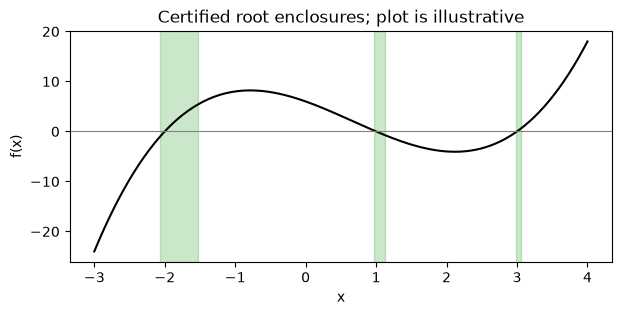

In [7]:
xs = np.linspace(-3, 4, 401)
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(xs, cubic(xs), color="black")
ax.axhline(0, color="gray", linewidth=0.8)
for certificate in search.certified:
    part = certificate.retained
    ax.axvspan(float(part.lo), float(part.hi), color="tab:green", alpha=0.25)
ax.set(xlabel="x", ylabel="f(x)", title="Certified root enclosures; plot is illustrative")
display(fig)
plt.close(fig)

The algebraically known roots −2, 1, 3 provide an independent diagnostic. The computational count follows from the certificates, their disjoint root enclosures, and the absence of unresolved regions. A list of three good-looking approximations would not supply that argument.

**AUDIT (10 minutes):** select a contraction record and explain why points outside its retained interval cannot be roots. Locate a subdivision record and check that both children were preserved.

## Failure cases · Multiple roots, boundaries, and budgets

For x² near zero, the derivative interval includes zero and the taught division is unavailable. For f(x)=x on [0,1], interval Newton reaches the boundary point {0}; strict interior inclusion does not succeed. Exact substitution proves that this point is a root, but this search intentionally has no separate boundary-root certification rule.

In [8]:
multiple = isolate_roots(lambda X: X.square(), lambda X: 2*X,
                         Interval(-1, 1), tolerance="1/100")
boundary = isolate_roots(lambda X: X, lambda X: Interval(1), Interval(0, 1))
limited = isolate_roots(cubic, cubic_derivative, Interval(-3, 4), max_steps=2)
for name, result in [("multiple root", multiple), ("boundary root", boundary), ("small budget", limited)]:
    print(name, result.status, "unresolved:", result.unresolved)
    assert result.unresolved
assert any(part.contains(0) for part in multiple.unresolved)
assert any(part.contains(0) for part in boundary.unresolved)

multiple root unresolved unresolved: [[-1/128, 0], [0, 1/128]]
boundary root unresolved unresolved: [[0, 0]]
small budget budget_exhausted unresolved: [[1/2, 4], [-5/4, 1/2], [-3, -5/4]]


## Exit ticket and reading

A search certifies two roots and returns three unresolved intervals. Write an accurate conclusion. Explain why declaring every small interval “one root” is invalid and why overlapping enclosures cannot simply be counted twice.

**Reading:** Tucker §§5.1.1–5.1.3, printed pp. 73–81, especially Theorem 5.5. Extended division and scalar Krawczyk in §§5.1.4–5.1.5 are optional. Next: [small nonlinear systems](10_nonlinear_systems.ipynb).